In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense, Input

In [2]:
train_df = pd.read_csv('Google_Stock_Price_Train.csv')
test_df = pd.read_csv('Google_Stock_Price_Test.csv')

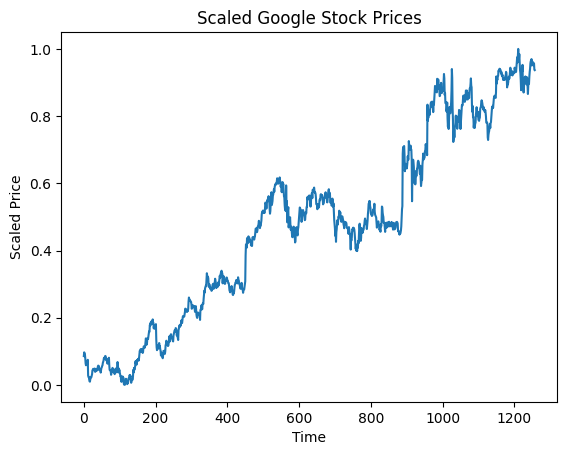

In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_df[['Open']].values)

plt.plot(train_scaled)
plt.title("Scaled Google Stock Prices")
plt.xlabel("Time")
plt.ylabel("Scaled Price")
plt.show()

In [4]:
time_step = 120 #use
x_train, y_train = [], []

for i in range(time_step, train_scaled.shape[0]):
    x_train.append(train_scaled[i-time_step:i, 0])
    y_train.append(train_scaled[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [5]:
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [6]:
model = Sequential([
    Input(shape=(x_train.shape[1], 1)),
    LSTM(100, activation='tanh', return_sequences=True), Dropout(0.3),
    LSTM(100, activation='tanh'), Dropout(0.3),
    Dense(1)
])

model.compile(optimizer='adam', loss='mae')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 120, 100)       │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 120, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,301 (473.83 KB)

 Trainable params: 121,301 (473.83 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.fit(x_train, y_train, epochs=20, batch_size=50, validation_split=0.05)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step - loss: 0.1251 - val_loss: 0.1570
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - loss: 0.0533 - val_loss: 0.0331
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 144ms/step - loss: 0.0485 - val_loss: 0.0243
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step - loss: 0.0441 - val_loss: 0.0355
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step - loss: 0.0424 - val_loss: 0.0301
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step - loss: 0.0419 - val_loss: 0.0242
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - loss: 0.0392 - val_loss: 0.0303
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step - loss: 0.0401 - val_loss: 0.0274
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step - loss: 0.0406 - val_loss: 0.0223
Epoch 10/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - loss: 0.0390 - val_loss: 0.0364
Epoch 11/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 142ms/step - loss: 0.0425 - val_loss: 0.0365
Epoch 12/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step

In [8]:
data = pd.concat((train_df['Open'], test_df['Open']), axis=0)
test_input = data[len(data) - len(test_df) - time_step:].values.reshape(-1, 1)

test_scaled = scaler.transform(test_input)

In [9]:
x_test = []
for i in range(time_step, test_scaled.shape[0]):
    x_test.append(test_scaled[i-time_step:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

In [10]:
y_pred = model.predict(x_test)
y_pred = scaler.inverse_transform(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step


In [11]:
y_test = test_df['Open'].values


In [12]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 37.13614981648928


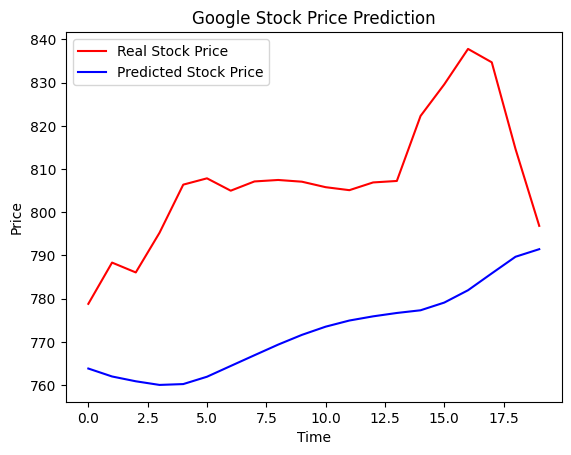

In [13]:
plt.plot(y_test, color='red', label='Real Stock Price')
plt.plot(y_pred, color='blue', label='Predicted Stock Price')
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()